## Sumário

0. Trilateração $\rightarrow $ https://www.youtube.com/watch?v=qufSJWkx58M

1. Triangulação

2. Fototriangulação

3. Aerotriangulação

## Requisitos

In [ ]:
!pip install pillow defusedxml xmptools numpy matplotlib pyproj geopandas contextily sympy requests gdown open3d scipy ipython-autotime opencv-python 

## 1. Triangulação

A triangulação é um método clássico de levantamento topográfico usado para determinar a posição de pontos no terreno através da medida de ângulos entre linhas que conectam pontos já conhecidos.

### Exemplo 1

Dois Teodolitos obtêm visadas do mesmo alvo $P$ sob pontos de vistas diferentes conhecidos. Como obter as coordenadas do alvo?

<img src="data/triangulacao_exemplo.png" width=500>

#### Solução do exemplo 1

$T_2 = T_1 + \overrightarrow{b}$

$\begin{cases}\cos{\theta_1} = \frac{<\overrightarrow{b}, \ \ \overrightarrow{T_1P} >}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |}
= \frac{\left(X_{1} - X_{2}\right) \left(X_{1} - X_{p}\right) + \left(Y_{1} - Y_{2}\right) \left(Y_{1} - Y_{p}\right) + \left(Z_{1} - Z_{2}\right) \left(Z_{1} - Z_{p}\right)}{\sqrt{\left(X_{1} - X_{2}\right)^{2} + \left(Y_{1} - Y_{2}\right)^{2} + \left(Z_{1} - Z_{2}\right)^{2}} \sqrt{\left(X_{1} - X_{p}\right)^{2} + \left(Y_{1} - Y_{p}\right)^{2} + \left(Z_{1} - Z_{p}\right)^{2}}} \\ \\\sin{\theta_1} = \frac{|\overrightarrow{b} \times \ \overrightarrow{T_1P} |}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} = \frac{\sqrt{\left(\left(X_{1} - X_{2}\right) \left(Y_{1} - Y_{p}\right) - \left(X_{1} - X_{p}\right) \left(Y_{1} - Y_{2}\right)\right)^{2} + \left(\left(X_{1} - X_{2}\right) \left(Z_{1} - Z_{p}\right) - \left(X_{1} - X_{p}\right) \left(Z_{1} - Z_{2}\right)\right)^{2} + \left(\left(Y_{1} - Y_{2}\right) \left(Z_{1} - Z_{p}\right) - \left(Y_{1} - Y_{p}\right) \left(Z_{1} - Z_{2}\right)\right)^{2}}}{\sqrt{\left(X_{1} - X_{2}\right)^{2} + \left(Y_{1} - Y_{2}\right)^{2} + \left(Z_{1} - Z_{2}\right)^{2}} \sqrt{\left(X_{1} - X_{p}\right)^{2} + \left(Y_{1} - Y_{p}\right)^{2} + \left(Z_{1} - Z_{p}\right)^{2}}}\\ \\\cos{\theta_2} = \frac{<\overrightarrow{b}, \ \ \overrightarrow{T_2P} >}{|\overrightarrow{b} | . |\overrightarrow{T_2P} |} = \frac{\left(X_{1} - X_{2}\right) \left(X_{2} - X_{p}\right) + \left(Y_{1} - Y_{2}\right) \left(Y_{2} - Y_{p}\right) + \left(Z_{1} - Z_{2}\right) \left(Z_{2} - Z_{p}\right)}{\sqrt{\left(X_{1} - X_{2}\right)^{2} + \left(Y_{1} - Y_{2}\right)^{2} + \left(Z_{1} - Z_{2}\right)^{2}} \sqrt{\left(X_{2} - X_{p}\right)^{2} + \left(Y_{2} - Y_{p}\right)^{2} + \left(Z_{2} - Z_{p}\right)^{2}}}\\ \\\sin{\theta_2} = \frac{|\overrightarrow{b} \times \ \overrightarrow{T_2P} |}{|\overrightarrow{b} | . |\overrightarrow{T_2P} |} = \frac{\sqrt{\left(\left(X_{1} - X_{2}\right) \left(Y_{2} - Y_{p}\right) - \left(X_{2} - X_{p}\right) \left(Y_{1} - Y_{2}\right)\right)^{2} + \left(\left(X_{1} - X_{2}\right) \left(Z_{2} - Z_{p}\right) - \left(X_{2} - X_{p}\right) \left(Z_{1} - Z_{2}\right)\right)^{2} + \left(\left(Y_{1} - Y_{2}\right) \left(Z_{2} - Z_{p}\right) - \left(Y_{2} - Y_{p}\right) \left(Z_{1} - Z_{2}\right)\right)^{2}}}{\sqrt{\left(X_{1} - X_{2}\right)^{2} + \left(Y_{1} - Y_{2}\right)^{2} + \left(Z_{1} - Z_{2}\right)^{2}} \sqrt{\left(X_{2} - X_{p}\right)^{2} + \left(Y_{2} - Y_{p}\right)^{2} + \left(Z_{2} - Z_{p}\right)^{2}}}\end{cases} $

### Exemplo 2 

Três ou mais Teodolitos obtêm visadas do mesmo alvo $P$ sob pontos de vistas diferentes conhecidos. Como obter as coordenadas do alvo?


<img src="data/triangulacao_exemplo2.png" width=500>

#### Solução do exemplo 2

$$T_2 = T_1 + \overrightarrow{b}$$
$$T_3 = T_1 + \overrightarrow{b} + \overrightarrow{c}$$

Sistema de equações redundante:

$\begin{cases}\cos{\theta_1} = \frac{<\overrightarrow{b}, \ \ \overrightarrow{T_1P} >}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} \ \ \rightarrow (f_1) \\ \\\sin{\theta_1} = \frac{|\overrightarrow{b} \times \ \overrightarrow{T_1P} |}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} \ \ \rightarrow (f_2) \\ \\\cos{\theta_2} = \frac{<-\overrightarrow{b}, \ \ \overrightarrow{T_2P} >}{|-\overrightarrow{b} | . |\overrightarrow{T_2P} |} \ \ \rightarrow (f_3) \\ \\\sin{\theta_2} = \frac{|-\overrightarrow{b} \times \ \overrightarrow{T_2P} |}{|-\overrightarrow{b} | . |\overrightarrow{T_2P} |} \ \ \rightarrow (f_4) \\ \\\cos{\theta_3} = \frac{<-\overrightarrow{c}, \ \ \overrightarrow{T_3P} >}{|-\overrightarrow{c} | . |\overrightarrow{T_3P} |} \ \ \rightarrow (f_5) \\ \\\sin{\theta_3} = \frac{|-\overrightarrow{c} \times \ \overrightarrow{T_3P} |}{|-\overrightarrow{c} | . |\overrightarrow{T_3P} |} \ \ \rightarrow (f_6) \end{cases}$

### (i) Relembrando ajustamento MMQ para sistema de equações não lineares

$F(X_a) = F(X_0 + X) = L_a = L_b + V $, onde:
- $F$ é uma função não linear;
- $L_b$ é o vetor de observações com erros;
- $X_a$ é o vetor de incógnitas ajustadas;
- $L_a$ é o vetor de observações ajustadas;
- $V$ é o vetor de resíduos;
- $X_0$ é vetor com valores aproximados dos parâmetros, converge para $X_a$ após algumas iterações;
- $X$ é o Vetor correção (incremento) dentro de uma iteração, converge para $0$ após algumas iterações;

Neste caso, expandindo o termo $L_b + V = F(X_0 + X)$ pela série de Taylor e
desprezando os termos maiores ou iguais a 2, tem-se:

$$
L_b + V = F(X_0 + X) ≈ \underbrace{F(X_0)}_{L_0}+ \underbrace{\frac{dF}{dX} \bigg\rvert_{X=X_0}}_{A}  (X_a-X_0) 
$$
$$
\Phi = V^TV = (\underbrace{L_0-L_b}_{L}+A\underbrace{(X_a-X_0)}_{X})^T(\underbrace{L_0-L_b}_{L}+A\underbrace{(X_a-X_0)}_{X}) = (AX+L)^T(AX+L) = min  
$$
$$
\frac{d\Phi}{dX} \bigg\rvert_{X=X_a} = 2A^TAX + 2A^TL = 0
$$
$$
X = -(A^TA)^{-1}A^TL
$$

- $A$ é a matriz das derivadas parcias da função não linear em relação às incógnitas (parâmetros);
- $L_0$ é a função dos parâmetros aproximados, converge para $L_a$ após algumas iterações;;
- $V$ é o vetor de resíduos;
- $V=AX+L$ é o modelo linearizado do método paramétrico.

O resultado da equação (3) é utilizada para atualizar o valor de $X_0$ e $L_0$ para a iteração seguinte:

$$
X_a = X^{(2)}_0 = X^{(1)} + X_0^{(1)} 
$$
$$
L_a = L^{(2)}_0 = AX^{(1)} + L_0^{(1)}
$$
$$
L^{(2)} = L^{(2)}_0 - L_b 
$$
$$
A^{(2)} = \frac{dF}{dX} \bigg\rvert_{X=X^{(2)}_0}
$$
$$
X^{(2)} = -({A^{(2)}}^TA^{(2)})^{-1}{A^{(2)}}^TL^{(2)} 
$$

E assim até que $X^{(i)}$ se reduza a 0 com determinado grau de tolerânica arbitrário.

#### Para encaixar nosso problema nesta modelagem, partindo do sistema de equações, temos:

$$
F(X_a) = F\begin{pmatrix}X_p \\  Y_p \\ Z_p \end{pmatrix} =\begin{bmatrix}f_1(X_a) \\  f_2(X_a) \\ f_3(X_a) \\ f_4(X_a) \\ f_5(X_a) \\ f_6(X_a) \end{bmatrix} = 
\begin{bmatrix}
    \frac{<\overrightarrow{b}, \ \ \overrightarrow{T_1P} >}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} \\
    \frac{|\overrightarrow{b} \times \ \overrightarrow{T_1P} |}{|\overrightarrow{b} | . |\overrightarrow{T_1P} |} \\
    \frac{<-\overrightarrow{b}, \ \ \overrightarrow{T_2P} >}{|-\overrightarrow{b} | . |\overrightarrow{T_2P} |} \\
    \frac{|-\overrightarrow{b} \times \ \overrightarrow{T_2P} |}{|-\overrightarrow{b} | . |\overrightarrow{T_2P} |} \\
    \frac{<-\overrightarrow{c}, \ \ \overrightarrow{T_3P} >}{|-\overrightarrow{c} | . |\overrightarrow{T_3P} |} \\
    \frac{|-\overrightarrow{c} \times \ \overrightarrow{T_3P} |}{|-\overrightarrow{c} | . |\overrightarrow{T_3P} |}
\end{bmatrix} \\
L_b+V = \begin{bmatrix}
\cos{\theta_1} + v_1 \\
\sin{\theta_1} + v_2 \\
\cos{\theta_2} + v_3 \\
\sin{\theta_2} + v_4 \\
\cos{\theta_3} + v_5 \\
\sin{\theta_3} + v_6
\end{bmatrix}
$$

Assim:

$$
A =
\begin{bmatrix}
\frac{df_1}{dX_a} \\
\frac{df_2}{dX_a} \\
\frac{df_3}{dX_a} \\
\frac{df_4}{dX_a} \\
\frac{df_5}{dX_a} \\
\frac{df_6}{dX_a} \\
\end{bmatrix} =
\begin{bmatrix}
  \frac{\partial f_1}{\partial X_p} & \frac{\partial f_1}{\partial Y_p} & \frac{\partial f_1}{\partial Z_p} \\
  \frac{\partial f_2}{\partial X_p} & \frac{\partial f_2}{\partial Y_p} & \frac{\partial f_2}{\partial Z_p} \\
  \frac{\partial f_3}{\partial X_p} & \frac{\partial f_3}{\partial Y_p} & \frac{\partial f_3}{\partial Z_p} \\
  \frac{\partial f_4}{\partial X_p} & \frac{\partial f_4}{\partial Y_p} & \frac{\partial f_4}{\partial Z_p} \\
  \frac{\partial f_5}{\partial X_p} & \frac{\partial f_5}{\partial Y_p} & \frac{\partial f_5}{\partial Z_p} \\
  \frac{\partial f_6}{\partial X_p} & \frac{\partial f_6}{\partial Y_p} & \frac{\partial f_6}{\partial Z_p} \\
\end{bmatrix}
$$

Arbitrando $X^{(1)}_0 = [0 \ 0 \ 0]$, obtemos $L^{(1)}_0 = F(X^{(1)}_0)$ para a 1ª iteração. devemos encontrar $X^{(1)}$ através do método descrito pela equação (4), repetindo os cálculos até a tolerânica desejada.

#### Implementação da solução

X0:
 [0 0 0]
Lb:
 [[0.8       ]
 [0.6       ]
 [0.31622777]
 [0.9486833 ]
 [0.70710678]
 [0.70710678]]
L:
 [[-0.65857864]
 [ 0.38994949]
 [ 0.17991117]
 [-0.08044016]
 [-0.19261103]
 [ 0.15038614]]
A:
array([[ 0.29698485, -0.09899495],
       [-0.04242641,  0.01414214],
       [-0.13357587,  0.2003638 ],
       [ 0.07632907, -0.1144936 ],
       [-0.05044076,  0.20176304],
       [ 0.03026446, -0.12105782]])
X:
 [2.94491091 1.47329834 0.        ]
Erro:
 3.292887525721908

Xa:
 [2.94491091 1.47329834 0.        ]
L:
 [[ 0.17969479]
 [-0.3995053 ]
 [-0.66797217]
 [-0.01258722]
 [ 0.22747289]
 [-0.35135287]]
A:
array([[ 0.05006883,  0.06378418],
       [-0.24465569, -0.3116742 ],
       [-1.75804718,  0.1838787 ],
       [-0.66059805,  0.06909366],
       [ 0.12591585,  0.28069492],
       [-0.33078594, -0.73739672]])
X:
 [-0.38731549 -0.44490636  0.        ]
Erro:
 0.5898770665994508

Xa:
 [2.55759542 1.02839198 0.        ]
L:
 [[ 0.10537796]
 [-0.17539341]
 [-0.35258789]
 [ 0.05065545]
 

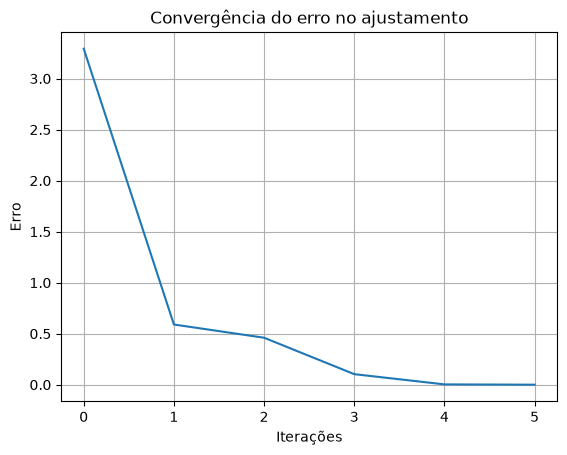

In [9]:
# imports
from sympy import symbols, Matrix, sqrt, simplify, diff, cos, sin, pi
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt

# Valores numéricos para o teste
dados = {"X_1": 1, "Y_1": 3 , "Z_1": 0, 
         "X_b": 2, "Y_b": -1, "Z_b": 0,
         "X_2": 3, "Y_2": 2 , "Z_2": 0,
         "X_c": 1, "Y_c": -1, "Z_c": 0,
         "X_3": 4, "Y_3": 1 , "Z_3": 0,
         "theta1": 36.86989765*np.pi/180,
         "theta2": 71.56505117707799*np.pi/180,
         "theta3": 45*np.pi/180}
# X_a = {X_p: 2, Y_p: 1, Z_p: 0} # solucao_esperada ao final do ajustamento

def cos_sin_theta(P, Tn, t):
    # Vetores
    TnP = P - Tn

    # Cosseno do ângulo entre os vetores
    cos_theta = simplify(t.dot(TnP) / (sqrt(t.dot(t)) * sqrt(TnP.dot(TnP))))

    # Seno do ângulo entre os vetores
    cross = t.cross(TnP)
    sen_theta = simplify( sqrt(cross.dot(cross)) / (sqrt(t.dot(t)) * sqrt(TnP.dot(TnP))))

    return cos_theta, sen_theta

# Definindo as variáveis simbólicas
X_b, Y_b, Z_b = symbols('X_b Y_b Z_b')
X_c, Y_c, Z_c = symbols('X_c Y_c Z_c')
X_p, Y_p, Z_p = symbols('X_p Y_p Z_p')
X_1, Y_1, Z_1 = symbols('X_1 Y_1 Z_1')
X_2, Y_2, Z_2 = symbols('X_2 Y_2 Z_2')
X_3, Y_3, Z_3 = symbols('X_3 Y_3 Z_3')

# Vetores
T1 = Matrix([X_1, Y_1, Z_1])
P = Matrix([X_p, Y_p, Z_p])

b = Matrix([X_b, Y_b, Z_b])
T2 = T1 + b
# T2 = Matrix([X_2, Y_2, Z_2])

c = Matrix([X_c, Y_c, Z_c])
T3 = T1 + b + c
# T3 = Matrix([X_3, Y_3, Z_3])

f1, f2 = cos_sin_theta(P, T1, b)
f3, f4 = cos_sin_theta(P, T2, -b)
f5, f6 = cos_sin_theta(P, T3, -c)

F = Matrix([[f1],
            [f2],
            [f3],
            [f4],
            [f5],
            [f6]])
# F = F.subs(dados)

# Derivadas parciais
df1_Xp, df1_Yp, df1_Zp = diff(f1, X_p), diff(f1, Y_p), diff(f1, Z_p)
df2_Xp, df2_Yp, df2_Zp = diff(f2, X_p), diff(f2, Y_p), diff(f2, Z_p)
df3_Xp, df3_Yp, df3_Zp = diff(f3, X_p), diff(f3, Y_p), diff(f3, Z_p)
df4_Xp, df4_Yp, df4_Zp = diff(f4, X_p), diff(f4, Y_p), diff(f4, Z_p)
df5_Xp, df5_Yp, df5_Zp = diff(f5, X_p), diff(f5, Y_p), diff(f5, Z_p)
df6_Xp, df6_Yp, df6_Zp = diff(f6, X_p), diff(f6, Y_p), diff(f6, Z_p)

# Montando a matriz Jacobiana
# A = Matrix([[df1_Xp, df1_Yp, df1_Zp],
#             [df2_Xp, df2_Yp, df2_Zp],
#             [df3_Xp, df3_Yp, df3_Zp],
#             [df4_Xp, df4_Yp, df4_Zp],
#             [df5_Xp, df5_Yp, df5_Zp],
#             [df6_Xp, df6_Yp, df6_Zp]]) # 3ª coluna = 0 => não é necessária
A = Matrix([[df1_Xp, df1_Yp],
            [df2_Xp, df2_Yp],
            [df3_Xp, df3_Yp],
            [df4_Xp, df4_Yp],
            [df5_Xp, df5_Yp],
            [df6_Xp, df6_Yp]]) 

### Início do ajustametno 
# Inicializações
# set X0
X_0 = {X_p: 0, Y_p: 0, Z_p: 0} 
print("X0:\n", np.array(list(X_0.values())))

# mount Lb
Lb = np.array([[np.cos(dados["theta1"])],
               [np.sin(dados["theta1"])],
               [np.cos(dados["theta2"])],
               [np.sin(dados["theta2"])],
               [np.cos(dados["theta3"])],
               [np.sin(dados["theta3"])]])
print("Lb:\n", Lb)

values = {**dados, **X_0}

erros = [] # guardar cada erro durante as iterações para compor um gráfico
erro = 10000000
while erro>10e-6:
    # update L0 = F(X0)
    L0 = np.array(F.subs(values).evalf().tolist(), dtype=float)
    # update L
    L = L0 - Lb
    print("L:\n", L)
    # update A
    a = np.array(A.subs(values).evalf().tolist(), dtype=float)
    print("A:")
    pprint(a)
    # update X = vetor das correções
    X = -np.linalg.inv(a.T @ a) @ a.T @ L
    # Devido ao corte da 3ª coluna da jacobinana A é necessario adicionar [0]
    # para manter o tamanho do vetor de correções das incógnitas X coerente
    # com o vetor de incógnitas ajustado X_0
    X = np.append(X, [0]) 
    print("X:\n", X)
    # update erro
    erro = np.linalg.norm(X)
    erros.append(erro)
    print("Erro:\n", erro)
    # update X0
    X0 = X + np.array(list(X_0.values()))
    print("\nXa:\n", X0)
    X_0 = {X_p: X0[0], Y_p: X0[1], Z_p: 0} 
    # update lista de valores para a próxima iteração
    values = {**dados, **X_0}

# Gráfico
plt.title("Convergência do erro no ajustamento")
plt.xlabel("Iterações")
plt.ylabel("Erro")
plt.grid()
plt.plot(erros)
plt.show()

## 2. Fototriangulação

A fototriangulação é um conjunto de métodos utilizado para determinar as coordenadas tridimensionais de pontos no terreno através de fotografias.

### (ii) Relembrando modelo da câmera de orifício

| Modelo da câmera de orifício     | Parâmetros |
| ------------- | ------------- | 
| <img src="data/pinhole_camera_model.png" style="background-color: white;"> | Sistemas de referência:<br>• $[X_w \ Y_w\  Z_w]$ são as coordenadas do ponto de interesse no sistema de referência do espaço-objeto;<br>• $[X_c\  Y_c\ Z_c]$ são as  coordenadas do ponto de interesse no sistema de referência da câmera;<br>• $[x \ y]$ são as coordenadas do ponto de interesse no plano do sensor em [mm], também chamado de eixo ótico;<br>• $[u\ v]$ são as coordenadas coluna e linha do ponto de interesse no plano do imagem em [pixels]. <br><br> Dados:<br>  • $f$ é a distância focal;<br>  • $[X_w^O \ Y_w^O\  Z_w^O]=O=CP$ é o Centro de projeção, também chamado de Centro de perspectiva; <br>  • $[X_w^P \ Y_w^P\  Z_w^P]=P$ é o ponto-objeto;<br>  • $[X_w^p \ Y_w^p\  Z_w^p]=p$ é o ponto-imagem;<br>• $[c_x \ c_y]$ é o ponto principal, ou seja, a projeção de $O$ no sistema-imagem | 



Observações: 

- O sistema-imagem [coluna, linha] ($[u, \ v]$) em pixels está sujeito a erros sitemáticos que induzem a não ortogonalidade de seus eixos e a uma rotação da imagem, além de distorções radiais e tangenciais oriundas das lentes;
- O sistema do eixo ótico $[x, \ y]$ em mm está transladado em aproximadamente $TotalColunas/2$ e $TotalLinhas/2$; e
- O fator de escala do espaço imagem pode não ser constante, ou seja, a largura do pixel em mm é diferente da altura do pixel em mm.

### (iii) Relembrando orientação interior

<b>Orientação interior: </b>reconstrução da geometria do feixe perspectivo, isto é, da posição do plano de imagem em relação
 ao eixo óptico da câmara fotográfica (sensor).

<img src="data/Orientação interior.png" width=600>     

<b> Modelo matemático da transformação afim geral:</b> 
- Ajustamento de 6 parâmetros ($a_i$\| $i=0,1,2,3,4,5$)<br> 
- Não há ortogonalidade entre eixos $(Col,Lin)$ e $(x,y)$ 
- Sistema pixel rotacionado;
- O sistema do eixo ótico $[x, \ y]$ em mm está transladado em aproximadamente $TotalColunas/2$ e $TotalLinhas/2$;
- Eixo $y$ invertido em relação ao eixo $Lin$;
- Diferentes escalas em $x$ e $y$
- Câmera introduz 04 marcas fiduciais na imagem para auxílio;
- Cada marca introduz 2 equações: 
    - $x_i = a_0 + a_1col_i + a_2lin_i$ 
    - $y_i = a_3 + a_4col_i + a_5lin_i$
- As 8 equações acima rearranjadas para que os parâmetros fiquem isolados e em forma matricial:
    - $ \underbrace{\begin{bmatrix}x_1\\y_1\\ x_2\\y_2\\ x_3\\y_3\\ x_4\\y_4\\\end{bmatrix}}_{L_b} = 
        \underbrace{\begin{bmatrix}1 & col_1 & lin_1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & col_1 & lin_1 \\
                    1 & col_2 & lin_2 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & col_2 & lin_2 \\
                    1 & col_3 & lin_3 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & col_3 & lin_3 \\
                    1 & col_4 & lin_4 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & col_4 & lin_4 \\
        \end{bmatrix} }_{A}
        \underbrace{\begin{bmatrix}a_0\\ a_1 \\ a_2\\a_3 \\ a_4 \\ a_5\end{bmatrix}}_{X} \rightarrow X_a = (A^TA)^{-1}A^TL_b$

Após a orientação interior, por semelhança de triângulos obtêm-se as relações entre o sistemas de referência da câmera e o plano do sensor:

$$\frac{x}{X_C}=\frac{f}{Z_c} $$

$$\frac{y}{Y_C}=\frac{f}{Z_c}$$


<b> Modelo matemático da matriz de parâmetros intrínsecos ($K$)</b>:

- Não há ajustamento, pois a câmera não insere marcas fiduciais;
- Modelagem das distorções feitas em separado;
- Devem ser conhecidos o tamanho do sensor, ou seja, a largura do pixel $s_x$, a altura do pixel $s_y$ e a distância focal $f$, todos em mm;
- Há ortogonalidade entre eixos $(Col,Lin)$ e $(x,y)$ ;
- O sistema do eixo ótico $[x, \ y]$ em mm está transladado em aproximadamente $c_x = TotalColunas/2$ e $c_y = TotalLinhas/2$;
- Eixo $y$ invertido em relação ao eixo $Lin$;
- Diferentes escalas em $x$ e $y$, ou seja, $s_x= \frac{LarguraImagem(mm)}{TotalColunas(px)} \ne \frac{AlturaImagem(mm)}{TotalLinhas(px)} = s_y$;
- As equações são: 
    - $col = x/s_x + c_x $ 
    - $lin = -y/s_y + c_y $
    - $x=\frac{fX_c}{Z_c} $
    - $y=\frac{fY_c}{Z_c}$
- A equação de transformação do sistema de referência da câmera para o plano da imagem:
    $$col = \frac{1}{s_x}f\frac{X_c}{Z_c} + c_x $$
    $$lin = -\frac{1}{s_y}f\frac{Y_c}{Z_c} + c_y $$


$K$ guarda diretamente as relações entre o sistemas de referência da câmera e o plano da imagem. 

$ Z_c \begin{bmatrix} coluna \\ linha \\ 1 \end{bmatrix} =
\underbrace{\begin{bmatrix} f_x& 0 & c_x\\ 0 & -f_y &  c_y\\ 0& 0& 1\end{bmatrix}}_{K}
\begin{bmatrix} X_c \\ Y_c \\ Z_c \end{bmatrix} \rightarrow \begin{bmatrix} X_c \\ Y_c \\ Z_c \end{bmatrix} = K^{-1} \begin{bmatrix} coluna \cdot Z_c\\ linha \cdot Z_c\\ Z_c \end{bmatrix}$

Onde:

- $f$ é a distância focal em mm;
- $f_x = f/s_x$ é a distância focal em pixels na direção horizontal;
- $f_y = f/s_y$ é a distância focal em pixels na direção vertical (trocar o sinal negativo caso o eixo $y$ apontar na mesma direção do eixo $Lin$); e
- $[c_x \ c_y]$ é o ponto principal em pixels, ou seja, a projeção do centro de perspectiva (O) no sistema-imagem.

<b> Modelagem de distorções ($k_1 \ k_2 \ k_3 \ p_1 \ p_2 \ r$)</b>:

Correção da distorção radial:
$\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} x'(1+k_1r^2 + k_2r^4 + k_3r^6) \\ y'(1+k_1r^2 + k_2r^4 + k_3r^6)  \end{bmatrix}$

Correção da distorção tangencial:
$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} x''+ [2p_1x''y'' + p_2(r^2 + 2x''^2)]  \\ y''+ [2p_2x''y'' + p_1(r^2 + 2y''^2)] \end{bmatrix}$

<b> O fabricante da câmera não informa o tamanho do sensor ou distânica focal em mm (sx, sy ou f) mas sim o FOV</b>:

| Ângulos do campo de visada (FOV)     |  Relação FOV, f, fx e fy |
| ------------- | ------------- | 
| <img src="data/fov_relations.png" width=400> | • $\tan(\frac{FOV_{Hor}}{2})= \frac{w/2}{f}$<br>• $\tan(\frac{FOV_{Ver}}{2})= \frac{h/2}{f}$<br>• $\tan(\frac{FOV_{Diag}}{2})= \frac{d/2}{f}$<br>Estimativa grosseira para $f_x$ e $f_y$<br>• $f_x=f_y=f$ é a distância focal em pixels<br>Estimativa menos grosseira para $f_x$ e $f_y$<br>• $\frac{f_x}{w}=\frac{f_y}{h}=\frac{f}{d}$   | 

<b> A câmera é descohecida e não existe informações relevantes nos metadados</b>:

Um processo para encontrar a transformação $K$: [Calibração da câmera em uma padrão 2D.ipynb](https://github.com/HumbertoDiego/lidar-experiments/blob/main/Theory%201.1-CameraCalibration2DPattern.ipynb)

### (iv) Relembrando orientação exterior

<b>Orientação exterior: </b> obtenção da posição $C$ = ($X_w^0, \ Y_w^0, \ Z^0_w$) e orientação ($\phi,\omega,\kappa$) do sensor em relação ao referencial do espaço-objeto no momento em que a fotografia foi tirada. Permitindo assim, realizar a transformação de um ponto qualquer $P$ do espaço objeto para o espaço da câmera.

$R = R_z(\psi) \cdot R_y(\theta) \cdot R_x(\phi) \rightarrow$

$ \begin{bmatrix} X_c^P \\ Y_c^P \\ Z^P_c \end{bmatrix} = R \left (\begin{bmatrix} X_w^P \\ Y_w^P \\ Z^P_w \end{bmatrix} - \begin{bmatrix} X_w^0 \\ Y_w^0 \\ Z^0_w \end{bmatrix} \right ) = R \mathbf{X}_w - R \mathbf{C}$

É muito comum utilizar-se de uma única matriz para fazer as mesmas operações, a chamamos de matriz de parâmetros extrínsicos $T$:

$ \begin{bmatrix} X_c^P \\ Y_c^P \\ Z^P_c \end{bmatrix} = \underbrace{\begin{bmatrix}
                R_{3 \times 3} & t_{3\times 1} \\
                0_{1 \times 3} & 1 
            \end{bmatrix}}_{T}  \begin{bmatrix} X_w^P \\ Y_w^P \\ Z^P_w \end{bmatrix} = R \mathbf{X}_w + \mathbf{t}$

Onde: $\mathbf{t} = -R \mathbf{C}$

a) Pode ser obtido diretamente com sensores (GPS e IMU embarcados em drones, por exemplo), que os registram nos metadados da fotografia.

https://exifmeta.com/

Ou https://exiftool.org/

In [10]:
!.\thirdparty\exiftool\exiftool.exe -f -g data/DJI_0019.JPG

---- ExifTool ----
ExifTool Version Number         : 13.59
---- File ----
File Name                       : DJI_0019.JPG
Directory                       : data
File Size                       : 7.7 MB
Zone Identifier                 : Exists
File Modification Date/Time     : 2026:07:07 15:56:03-03:00
File Access Date/Time           : 2026:07:07 16:00:13-03:00
File Creation Date/Time         : 2026:07:07 15:56:05-03:00
File Permissions                : -rw-rw-rw-
File Type                       : JPEG
File Type Extension             : jpg
MIME Type                       : image/jpeg
Exif Byte Order                 : Little-endian (Intel, II)
Image Width                     : 4864
Image Height                    : 3648
Encoding Process                : Baseline DCT, Huffman coding
Bits Per Sample                 : 8
Color Components                : 3
Y Cb Cr Sub Sampling            : YCbCr4:2:2 (2 1)
---- EXIF ----
Image Description               : DCIM\101MEDIA\DJI_0019.JPG
Camera Mode

Ou Python PIL

In [11]:
from PIL import Image
from PIL.ExifTags import TAGS

image_path = 'data/DJI_0019.JPG'
image = Image.open(image_path)
exif_data = image._getexif()
exif_dict = {TAGS.get(tag): value for tag, value in exif_data.items()}

# Exibir informações EXIF
print("EXIF Data:")
for tag, value in exif_dict.items():
    print(f"{tag}: {value}")
    
# Exibir informações XMP
print("\nXMP Data:")
for tag, value in image.getxmp()['xmpmeta']['RDF']['Description'].items():
    print(f"{tag}: {value}")

EXIF Data:
GPSInfo: {0: b'\x02\x03\x00\x00', 1: 'S', 2: (3.0, 5.0, 24.3997), 3: 'W', 4: (60.0, 4.0, 34.1811), 5: b'\x00', 6: 176.072}
ResolutionUnit: 2
ExifOffset: 182
ImageDescription: DCIM\101MEDIA\DJI_0019.JPG
Make: DJI                          
Model: FC6310                       
Software: v01.07.1641            
Orientation: 1
DateTime: 2018:12:12 15:28:09
YCbCrPositioning: 1
XResolution: 72.0
YResolution: 72.0
XPComment: b'T\x00y\x00p\x00e\x00=\x00N\x00,\x00 \x00M\x00o\x00d\x00e\x00=\x00P\x00,\x00 \x00D\x00E\x00=\x00D\x00-\x00C\x00i\x00n\x00e\x00l\x00i\x00k\x00e\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

b) Pode ser obtidos por ajustamento da matriz de tranformação geral de um ponto no espaço-objeto para o espaço imagem ($camera \ matrix = projection \ matrix = \ P$), com no mínimo 6 pontos de controle no terreno:


$$Z_c
\begin{bmatrix}
u \\
v \\
1
\end{bmatrix}=
\underbrace{
        \underbrace{
            \begin{bmatrix}
                f_x & 0 & c_x & 0 \\
                0 & f_y & c_y & 0 \\
                0 & 0 & 1 & 0
            \end{bmatrix}
        }_{Intrinsic \ parameters \ [K_{3\times 3}|0]}
        \underbrace{
            \begin{bmatrix}
                R_{3 \times 3} & t_{3\times 1} \\
                0_{1 \times 3} & 1 
            \end{bmatrix}
        }_{Extrinsic \ parameters \ T_{4\times 4}}
}_{P_{3\times 4}}
\begin{bmatrix}
X \\
Y \\
Z\\
1
\end{bmatrix}  \ \ \ (3)
$$

$$
Z_w\begin{bmatrix}
    u \\
    v \\
    1
\end{bmatrix} = 
\begin{bmatrix}
    p_{11} & p_{12} & p_{13} & p_{14} \\
    p_{21} & p_{22} & p_{23} & p_{24} \\
    p_{31} & p_{32} & p_{33} & p_{34}
\end{bmatrix}
\begin{bmatrix}
    X_w \\
    Y_w \\
    Z_w \\
    1
\end{bmatrix} =
\begin{bmatrix}
    p_{11}X_w + p_{12}Y_w + p_{13}Z_w + p_{14} \\
    p_{21}X_w + p_{22}Y_w + p_{23}Z_w + p_{24} \\
    p_{31}X_w + p_{32}Y_w + p_{33}Z_w + p_{34}
\end{bmatrix} \\
$$
$$
u = \frac{p_{11}X_w + p_{12}Y_w + p_{13}Z_w + p_{14}}{p_{31}X_w + p_{32}Y_w + p_{33}Z_w + p_{34}} 
$$

$$
v = \frac{p_{21}X_w + p_{22}Y_w + p_{23}Z_w + p_{24}}{p_{31}X_w + p_{32}Y_w + p_{33}Z_w + p_{34}}
$$
$$
p_{11}X_w + p_{12}Y_w + p_{13}Z_w + p_{14} - up_{31}X_w - u p_{32}Y_w - u p_{33}Z_w - u p_{34} = 0
$$
$$
p_{21}X_w + p_{22}Y_w + p_{23}Z_w + p_{24} - vp_{31}X_w - v p_{32}Y_w - v p_{33}Z_w - v p_{34} = 0
$$

Rearrajando os termos para tranformar em uma multiplicação de matrizes temos: 

$$
\begin{bmatrix}
X_w & Y_w & Z_w & 1 & 0   & 0   & 0   & 0 & -uX_w & -uY_w & -uZ_w & -u \\
0   &  0  & 0   & 0 & X_w & Y_w & Z_w & 1 & -vX_w & -vY_w & -vZ_w & -v 
\end{bmatrix}
\begin{bmatrix}
 p_{11} \\
 p_{12} \\
 p_{13} \\
 p_{14} \\
 p_{21} \\
 p_{22} \\
 p_{23} \\
 p_{24} \\
 p_{31} \\
 p_{32} \\
 p_{33} \\
 p_{34}
\end{bmatrix} = 0
$$

E para o nosso conjunto de, no mínimo, 6 pontos homólogos, temos:

$$
\begin{bmatrix}
X_w^{(1)} & Y_w^{(1)} & Z_w^{(1)} & 1 & 0   & 0   & 0   & 0 & -u^{(1)}X_w^{(1)} & -u^{(1)}Y_w^{(1)} & -u^{(1)}Z_w^{(1)} & -u^{(1)} \\
0   &  0  & 0   & 0 & X_w^{(1)} & Y_w^{(1)} & Z_w^{(1)} & 1 & -v^{(1)}X_w^{(1)} & -v^{(1)}Y_w^{(1)} & -v^{(1)}Z_w^{(1)} & -v^{(1)} \\
\vdots &\vdots &\vdots &\vdots &\vdots &\vdots &\vdots&\vdots & \vdots &\vdots &\vdots &\vdots \\
X_w^{(n)} & Y_w^{(n)} & Z_w^{(n)} & 1 & 0   & 0   & 0   & 0 & -u^{(n)}X_w^{(n)} & -u^{(n)}Y_w^{(n)} & -u^{(n)}Z_w^{(n)} & -u^{(n)} \\
0   &  0  & 0   & 0 & X_w^{(n)} & Y_w^{(n)} & Z_w^{(n)} & 1 & -v^{(n)}X_w^{(n)} & -v^{(n)}Y_w^{(n)} & -v^{(n)}Z_w^{(n)} & -v^{(n)} \\
\end{bmatrix}
\begin{bmatrix}
 p_{11} \\
 p_{12} \\
 p_{13} \\
 p_{14} \\
 p_{21} \\
 p_{22} \\
 p_{23} \\
 p_{24} \\
 p_{31} \\
 p_{32} \\
 p_{33} \\
 p_{34}
\end{bmatrix} = 0 
$$

$$
\begin{bmatrix}A\end{bmatrix}_{2n \ \times \ 12}\ \begin{bmatrix}p\end{bmatrix}_{12 \ \times\ 1}=0 \rightarrow p_a \text{ é o autovetor correspondente ao menor autovalor de } A^TA 
$$ 


Um processo para ajustar $P$ e fatorá-lo em $K$, $R$ e $t$: [Calibração da câmera em uma padrão 3D.ipynb](https://github.com/HumbertoDiego/SFMTools/blob/main/calibra%C3%A7%C3%A3o_3DPattern.ipynb)

### Exemplo 3

Duas câmeras de parâmetros intrísecos já conhecidos (orientação interior realizada), obtêm fotografias que visam o alvo $P$ sob pontos de vistas diferentes. Como obter as coordenas tridimensionais do alvo?

<img src="data/fototriangulação_exemplo1.png" > 

Observações: 

- Neste exemplo, a escala é indefinida portanto pode ser arbritrada; 
- É possivel realizar a triangulação utilizando o sistema de referência da câmera 1; e
- A escala pode ser determinada se for conhecida a tranformação ${}_{objeto}T_{c1}$, do sistema da câmera 1 para o sistema de referência do objeto 
- A escala pode ser determinada utilizando-se pontos de controle de coordenadas conhecidas no espaço-objeto.

### Exemplo 4

Duas câmeras de parâmetros intrísecos e extríncios já conhecidos (orientação interior e exterior realizada), obtêm fotografias que visam o alvo $P$ sob pontos de vistas diferentes. Como obter as coordenas tridimensionais do alvo?

<img src="data/fototriangulação_exemplo2.png" >

#### Solução do exemplo 4

Parâmetros:

- $P$ : Matriz de transformação do sistema de referência do espaço-objeto para o sistema de referência do espaço-imagem em pixels;
- $\overrightarrow{p} = [u \ v]^T$: Coluna e linha observadas do pixel de pesquisa; e
- $\overrightarrow{X} = [X\tilde{w} \ Y\tilde{w} \ Z\tilde{w} \ \tilde{w}]^T$: Coordenada homogênea 3D, a ser estimada, do pixel de pesquisa no espaço-objeto.


Álgebra:

$\overrightarrow{p}_{predito} = P \overrightarrow{X} \rightarrow$ Deve ser colinear com o ponto observado $\overrightarrow{p} \rightarrow$

$
\overrightarrow{p} \times ( P \overrightarrow{X}) =0 \rightarrow 
$

$
\begin{bmatrix} u \\ v \\ 1 \end{bmatrix}  \times \left ( \begin{bmatrix} P^1 \\ P^2 \\ P^3 \end{bmatrix}_{3 \times 4} \begin{bmatrix}  X \tilde{w} \\ Y\tilde{w} \\ Z\tilde{w} \\ \tilde{w} \end{bmatrix} \right )  = 0 \rightarrow
$

$
\begin{bmatrix} uP^3 - P^1 \\ vP^3 - P^2 \\ uP^2 - vP^1 \end{bmatrix} \begin{bmatrix}  X \tilde{w} \\ Y\tilde{w} \\ Z\tilde{w} \\ \tilde{w} \end{bmatrix}= 0 \rightarrow \text{ mas } Linha_3 = uLinha_2 - vLinha_1 \rightarrow
$

$\begin{bmatrix} uP^3 - P^1 \\ vP^3 - P^2  \end{bmatrix} \begin{bmatrix}  X \tilde{w} \\ Y\tilde{w} \\ Z\tilde{w} \\ \tilde{w} \end{bmatrix}= 0
$

O problema ainda não tem solução, mas tendo duas câmeras e conhecidos suas matrizes de transformação do sistema de referência do espaço-objeto para o sistema de referência do espaço-imagem em pixels $P_1$ e $P_2$, bem como, as coordenadas coluna e linha de um pixel correspondente nas duas imagens $\overrightarrow{p_1}$ e $\overrightarrow{p_2}$, teríamos:

$\begin{bmatrix} u_{p1}P_1^3 - P_1^1 \\ v_{p1}P_1^3 - P_1^2 \\ u_{p2}P_2^3 - P_2^1 \\ v_{p2}P_2^3 - P_2^2  \end{bmatrix} \begin{bmatrix}  X \tilde{w} \\ Y\tilde{w} \\ Z\tilde{w} \\ \tilde{w} \end{bmatrix}= 0
$

$
 A\overrightarrow{X}=0 \xrightarrow{ajustamento}
$

$A\overrightarrow{X_a}=V$ sujeito a $||\overrightarrow{X_a}||=1 \rightarrow $

$\overrightarrow{X_a}$ estimado é o autovetor correspondente ao menor autovalor de $A^TA$.


#### Implementação do exemplo 4 - Qual a coordenada no espaço-objeto do olho esquerdo (ponto amarelo) da estátua de águia visto nas duas imagens?

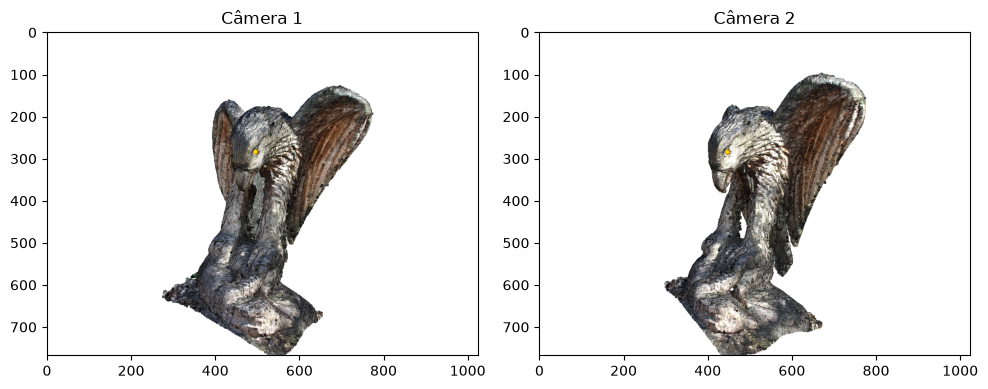

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
img1 = mpimg.imread('data/ScreenCapture_1.png')
img2 = mpimg.imread('data/ScreenCapture_2.png')

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the first image
axes[0].imshow(img1)
axes[0].set_title('Câmera 1')

# Display the second image
axes[1].imshow(img2)
axes[1].set_title('Câmera 2')

# Adjust layout
plt.tight_layout()
plt.show()

In [15]:
import json
import numpy as np

# Get Extrinsic and Intrinsic Parameters
camera_1 = json.load(open("data/ScreenCamera_1.json"))
camera_2 = json.load(open("data/ScreenCamera_2.json"))
camera_1_extrinsic = np.array(camera_1['extrinsic'], dtype=float).reshape(4,4).T
camera_2_extrinsic = np.array(camera_2['extrinsic'], dtype=float).reshape(4,4).T
camera_1_intrinsic = np.array(camera_1['intrinsic']['intrinsic_matrix'], dtype=float).reshape(3,3).T
camera_2_intrinsic = np.array(camera_2['intrinsic']['intrinsic_matrix'], dtype=float).reshape(3,3).T

print("camera_1_extrinsic T1:\n", camera_1_extrinsic)
print("camera_1_intrinsic K1:\n", camera_1_intrinsic)
print("camera_2_extrinsic T2:\n", camera_2_extrinsic)
print("camera_2_intrinsic K2:\n", camera_2_intrinsic)

# 3D coordinates:
# P = np.array([[-0.37045199], [1.50146997],  [0.79242003],  [1.]])
# Pixel coordinates
p1 = [496.0, 284.0]
p2 = [446.0, 285.0]

camera_1_extrinsic T1:
 [[ 0.57154125 -0.27825726 -0.77195434  1.03628981]
 [ 0.12981545  0.959564   -0.24976965 -2.48872951]
 [ 0.81023981  0.04254206  0.5845525   8.42181041]
 [ 0.          0.          0.          1.        ]]
camera_1_intrinsic K1:
 [[665.10751011   0.         511.5       ]
 [  0.         665.10751011 383.5       ]
 [  0.           0.           1.        ]]
camera_2_extrinsic T2:
 [[ 0.828596   -0.22834473 -0.51116275  0.18681261]
 [ 0.12993527  0.96654595 -0.22114646 -2.54734913]
 [ 0.54455991  0.116823    0.83054614  8.24664481]
 [ 0.          0.          0.          1.        ]]
camera_2_intrinsic K2:
 [[665.10751011   0.         511.5       ]
 [  0.         665.10751011 383.5       ]
 [  0.           0.           1.        ]]


Ajustamento:

In [16]:
P1 = camera_1_intrinsic @ camera_1_extrinsic[:-1]
P2 = camera_2_intrinsic @ camera_2_extrinsic[:-1]
P1_1 = P1[0] # 1ª linha de P1
P1_2 = P1[1] # 2ª linha de P1
P1_3 = P1[2] # 3ª linha de P1
P2_1 = P2[0] # 1ª linha de P2
P2_2 = P2[1] # 2ª linha de P2
P2_3 = P2[2] # 3ª linha de P2
u_p1 , v_p1 = p1
u_p2 , v_p2 = p2

A = np.array([u_p1 * P1_3 - P1_1,
              v_p1 * P1_3 - P1_2,
              u_p2 * P2_3 - P2_1,
              v_p2 * P2_3 - P2_2])
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A.T@A)

# Find the index of the minimum eigenvalue
min_index = np.argmin(eigenvalues)

# Get the minimum eigenvalue and corresponding eigenvector
min_eigenvalue = eigenvalues[min_index]
min_eigenvector = eigenvectors[:, min_index]

P_calc = min_eigenvector/min_eigenvector[-1] # Normalizando o vetor
print("P_calculado:\n", P_calc)

# Valores esperados e erro do ajustamento
P_esperado = np.array([[-0.37045199], [1.50146997],  [0.79242003],  [1.]]).T
print("P_esperado:\n", P_esperado)
print("Erro:\n", np.linalg.norm(P_calc -P_esperado))

P_calculado:
 [-0.38473997  1.5050688   0.77581814  1.        ]
P_esperado:
 [[-0.37045199  1.50146997  0.79242003  1.        ]]
Erro:
 0.022197310845505868


## 3. Aerotriangulação

A aerotriangulação é um conjunto de métodos utilizado para determinar as coordenadas tridimensionais de pontos no terreno através de fotografias aéreas.

### (v) Relembrando ângulos de atitude

Os ângulos de atitude ((pitch, roll, yaw), (arfagem, balanço, rumo), (phi, omega, kappa), (sim, talvez, não)) são ângulos de Euler que descreverem a orientação de um corpo rígido girante em um espaço euclidiano tridimensional inercial, ou seja, fixo.

| Ângulos de atitude     | Parâmetros |
| ------------- | ------------- | 
| <img src="data/Rotação.jpeg"> | • $R_{y}= \begin{bmatrix} cos(\phi) &0 & -sen(\phi)\\0&1&0\\sen(\phi)&0&cos(\phi) \end{bmatrix}$ <br>• $R_{x}= \begin{bmatrix} 1 &0 & 0\\0&cos(\omega)&sen(\omega)\\0&-sen(\omega)&cos(\omega) \end{bmatrix}$ <br>• $R_{z}= \begin{bmatrix} cos(\kappa) &sen(\kappa) & 0\\-sen(\kappa)&cos(\kappa)&0\\0&0&1 \end{bmatrix}$| 

#### Implementação da rotação geral (Rypr)

In [17]:
import numpy as np

# Clockwise rotation matrixes for right-hand axis OR 
# Counter clockwise for left-hand axis
def Ry(pitch):
  return np.array([[np.cos(pitch), 0, np.sin(pitch)],
                   [0            , 1,      0        ],
                   [-np.sin(pitch), 0, np.cos(pitch) ]])
def Rx(roll):
  return np.array([[1,        0      ,      0     ],
                   [0, np.cos(roll) , -np.sin(roll)],
                   [0, np.sin(roll), np.cos(roll)]])
def Rz(yaw):
  return np.array([[np.cos(yaw) ,-np.sin(yaw), 0],
                   [np.sin(yaw),np.cos(yaw), 0],
                   [0             ,0        , 1]])
def Rypr( yaw, pitch, roll ):
  # (pitch, roll, yaw)=(phi, omega, kappa) --> sim, talvez, não
  return Rz( np.deg2rad(yaw)) @ Ry(np.deg2rad(pitch)) @ Rx(np.deg2rad(roll))

# Teste se Rpry^T = Rpry^-1
pitch, roll, yaw = 180, 180, 0
R = Rypr(pitch, roll, yaw)
print(R)
print("R^T = R^-1? ",np.allclose(R.T, np.linalg.inv(R)))

[[ 1.00000000e+00 -1.22464680e-16 -1.22464680e-16]
 [-1.22464680e-16 -1.00000000e+00  1.49975978e-32]
 [-1.22464680e-16  0.00000000e+00 -1.00000000e+00]]
R^T = R^-1?  True


### (vi) Relembrando modelo da câmera aerofotogramétrica

| Modelo da câmera aerofotogramétrica | Parâmetros | 
| ------------- | :------------ |
| <img src="data/modelo_camera_aerofotogramétrica0.jpg" width=600> | • $P = (X'_P \ Y'_P \ Z'_P)$ <br> • $p = (x_p \ y_p \ f)$ <br> • $PP = (x_0 \ y_0 \ f)$ <br> • $O = (X'_0 \ Y'_0 \ Z'_0)$ <br>• Condição de colinearidade: <br> no momento da tomada da fotografia,<br> o ponto-objeto $P$, o centro de projeção <br> $O$ e o ponto-imagem $p$ formam uma <br> linha reta. |

| Correção pelos ângulos de atitude $(\phi,\omega,\kappa) \ne (0,0,0)$| Parâmetros | 
| ------------- | :------------ |
| <img src="data/modelo_camera_aerofotogramétrica.jpg" width=600> | No espaço-objeto: <br> • $O = (X_0 \ Y_0 \ Z_0)$ <br><br> Relação entre o espaço objeto<br> e o espaço objeto paralelo  ao <br> espaço-imagem: <br> • $\begin{bmatrix} X-X_0 \\ Y-Y_0 \\ Z-Z_0 \end{bmatrix}= R_{rpy} \begin{bmatrix} X'-X'_0 \\ Y'-Y'_0 \\ Z'-Z'_0 \end{bmatrix} $ <br> • $\begin{bmatrix} X'-X'_0 \\ Y'-Y'_0 \\ Z'-Z'_0 \end{bmatrix}= R_{rpy}^{-1} \begin{bmatrix} X-X_0 \\ Y-Y_0 \\ Z-Z_0 \end{bmatrix}$ <br><br> Onde: <br> • $R_{rpy}^{-1} = R_{rpy}^{T}$ |

### (vii) Relembrando orientação exterior aerofotogramétrica

| Abertura de clareira      | Medição da coordenada      | Plotagem |
| ------------- | ------------- | --------|
| ![image2.png](data/image2.png) | ![image3.png](data/image3.png) | ![image4.png](data/image4.png) |

In [ ]:
import requests 
import os

filename = 'coleta de pontos.mp4'
video_path = os.path.join("aux_data", filename)

if not os.path.exists(video_path):
    url = "https://drive.usercontent.google.com/download?id=1awR3k-sXaKCcYMwS3dcU6bVTQLZYaFHQ&export=download&authuser=0"
    r = requests.get(url)

    if r.status_code == 200:
        if not os.path.exists("aux_data"):
            os.mkdir("aux_data")
        video_path = os.path.join("aux_data", filename)
        if not os.path.exists(video_path):
            # Open a file in write-binary mode
            with open(video_path, 'wb') as file:
                # Write the content of the response to the file
                file.write(r.content)
            print("File downloaded and saved successfully.")
    else:
        print(f"Failed to download file. Status code: {r.status_code}")

# Play movie
from IPython.display import HTML
from base64 import b64encode
mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video controls  height="600" >
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

## Prática

Dados:

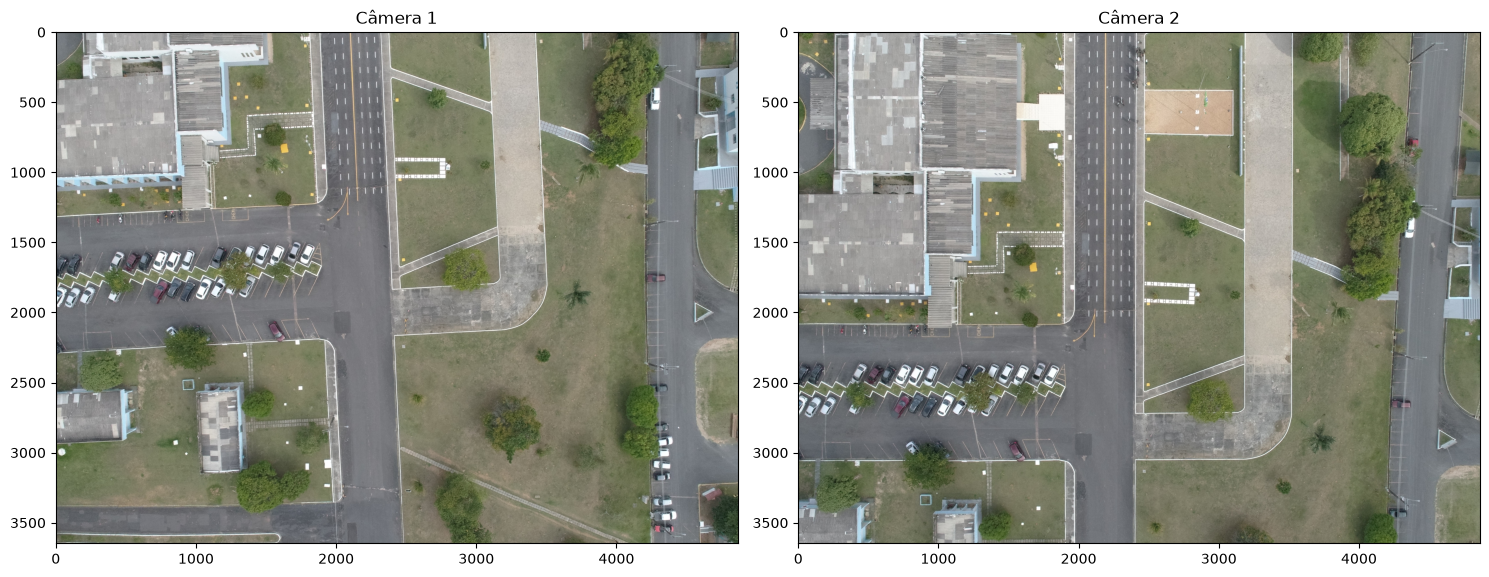

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
file1 = 'data/DJI_0019.JPG'
file2 = 'data/DJI_0020.JPG'
img1 = mpimg.imread(file1)
img2 = mpimg.imread(file2)

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# Display the first image
axes[0].imshow(img1)
axes[0].set_title('Câmera 1')

# Display the second image
axes[1].imshow(img2)
axes[1].set_title('Câmera 2')

# Adjust layout
plt.tight_layout()
plt.show()

Ponto de controle

   id                   desc              E             N     Z  \
0 NaN  centro bueiro amarelo  825043.600731  9.657984e+06  63.9   

                         geometry  
0  POINT (825043.601 9657983.628)  
EPSG:31980


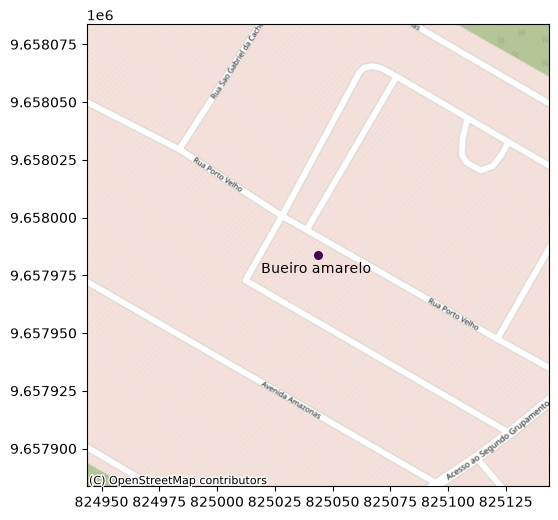

In [21]:
try:
    import geopandas as gpd
except ImportError:
    !pip install geopandas
    import geopandas as gpd

try:
    import contextily as cx
except ImportError:
    !pip install contextily
    import contextily as cx

import matplotlib.pyplot as plt

# Load the shapefile
gcp = gpd.read_file("data/gcp.shp")
# gcp = gdf.query('index == 1')

# Display the first few rows to see the points and EPSG
print(gcp.head())
print(gcp.crs)

# Plot the points
f, ax = plt.subplots(figsize=(8, 6))
gcp.plot(column="Z", ax=ax,  markersize=30)

# Extend the limits
ax.set_ylim(gcp["N"].min() - 100, gcp["N"].max() + 100 )
ax.set_xlim(gcp["E"].min() - 100, gcp["E"].max() + 100 )


ax.annotate(f'Bueiro amarelo',
            xy=(int(gcp.iloc[0]["E"]) , int(gcp.iloc[0]["N"])),
            xytext=(0, -14),  # 4 points vertical offset.
            textcoords='offset points',
            ha='center', va='bottom')

# Add basemap
# https://contextily.readthedocs.io/en/latest/intro_guide.html
cx.add_basemap(ax, 
               crs=gcp.crs.to_string(), 
               zoom =19,
               source=cx.providers.OpenStreetMap.Mapnik) 

plt.show()

#### Problema:

- Descobrir as coordenadas do ponto de controle descrito pelo centro do bueiro amarelo constantes das imagens 'data/DJI_0019.JPG' e 'data/DJI_0020.JPG'.
- gabarito = (825043.601,  9657983.628,  63.9)

Devido aos erros nas coordenadas GPS, bem como nas distorções não calibradas, será aceitável:
- Erro planimétrico < 10 m
- Erro altimétrico < 111 m

Dicas:
- https://www.dji.com/br/support/product/phantom-4-pro
- https://developer.dji.com/doc/payload-sdk-tutorial/en/function-set/advanced-function/media-file-metadata.html
- https://exiftool.org/TagNames/
<!-- - cv2.triangulatePoints() -->
<!-- - https://commonlands.com/blogs/technical/cmos-sensor-size -->

In [ ]:
# Imports


# Aux Functions e data


# (i) Extração das coordenadas do pixels nas duas imagens ($p_1$ e $p_2$ ) correspondente ao GCP conhecido:


# (ii) Extração da matrizes Extrínsicas ($T_1$ e $T_2$) e Intrísica ($K_1$ e $K_2$) dos metadados das imagens:


# (iii) Cálculo das matrizes de projeção das coordenadas do espaço-objeto para o espaço-imagem ($P_1$ e $P_2$):


# (iv) Ajustamento

